In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from filtering import butter_lowpass_filter, spline_baseline_remove, invert_signal
from segmenting import find_segments
from normalising import min_max_scaler, right_pad_or_crop
from resnet16 import ResNet16_Masked

In [ ]:
SAMPLING_RATE = 100  # Hz
NUM_OF_SEGMENTS = 15

In [139]:
# ppg signal data contains time, red and ir values
directory = ""
filename= "test_data.csv"
ppg_signal_data = pd.read_csv(directory + filename)
# Extract the red and ir signals
red_signal = invert_signal(ppg_signal_data["RED"])
ir_signal = invert_signal(ppg_signal_data["IR"])

In [140]:
signal_denoised = butter_lowpass_filter(red_signal, cutoff=10, fs=SAMPLING_RATE, order=3)

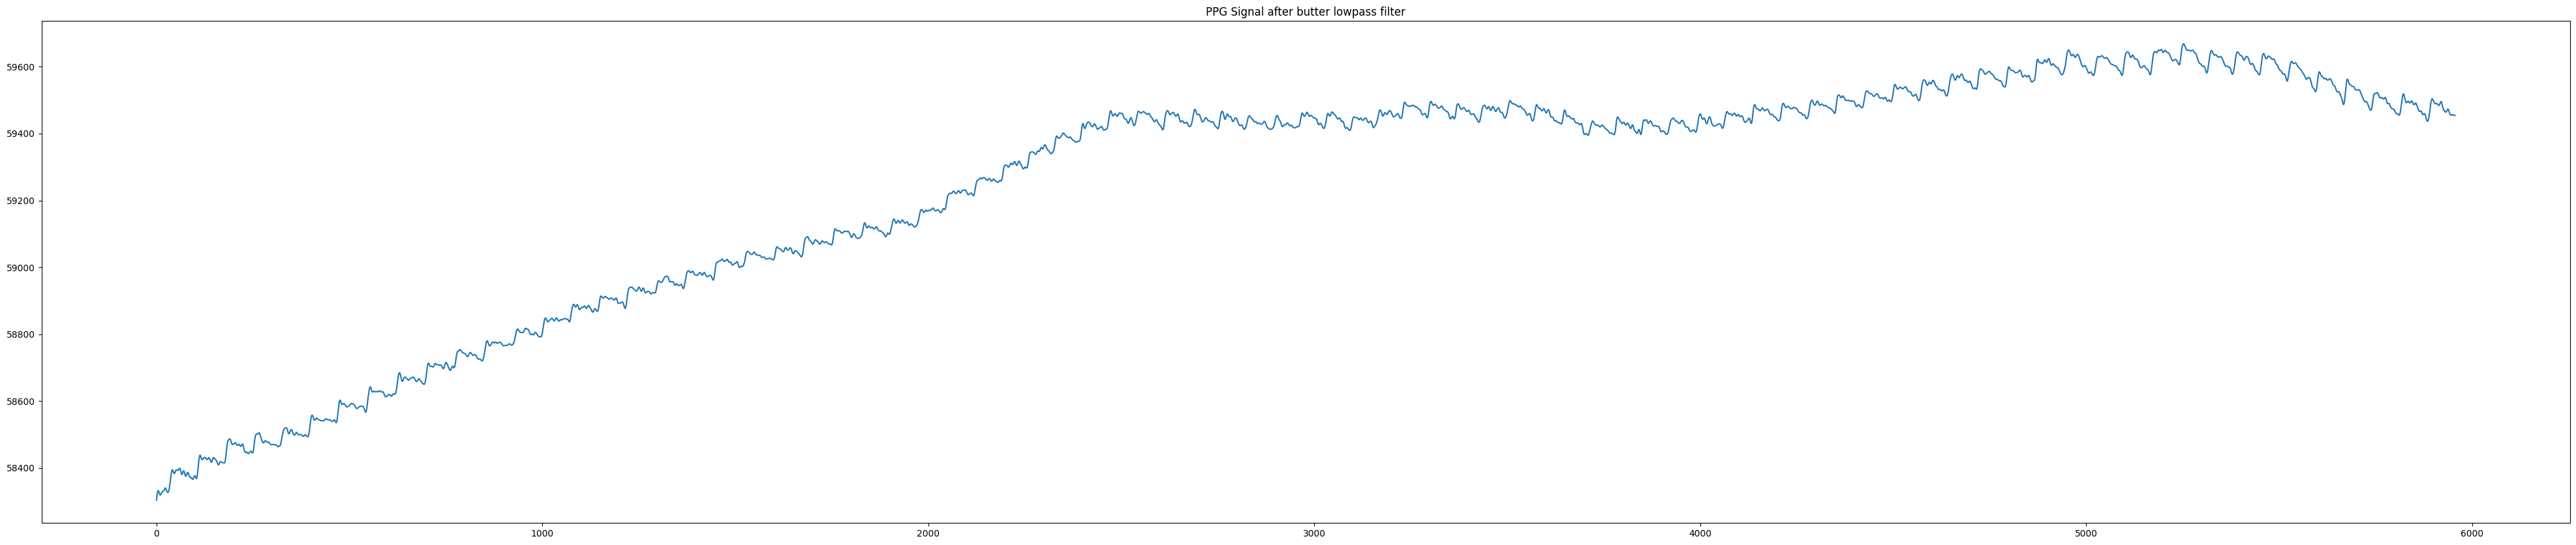

In [141]:
plt.figure(figsize=(50, 10))
plt.plot(signal_denoised)
plt.title("PPG Signal after butter lowpass filter")
plt.show()

In [142]:
signal_clean = spline_baseline_remove(signal_denoised, fs=SAMPLING_RATE)

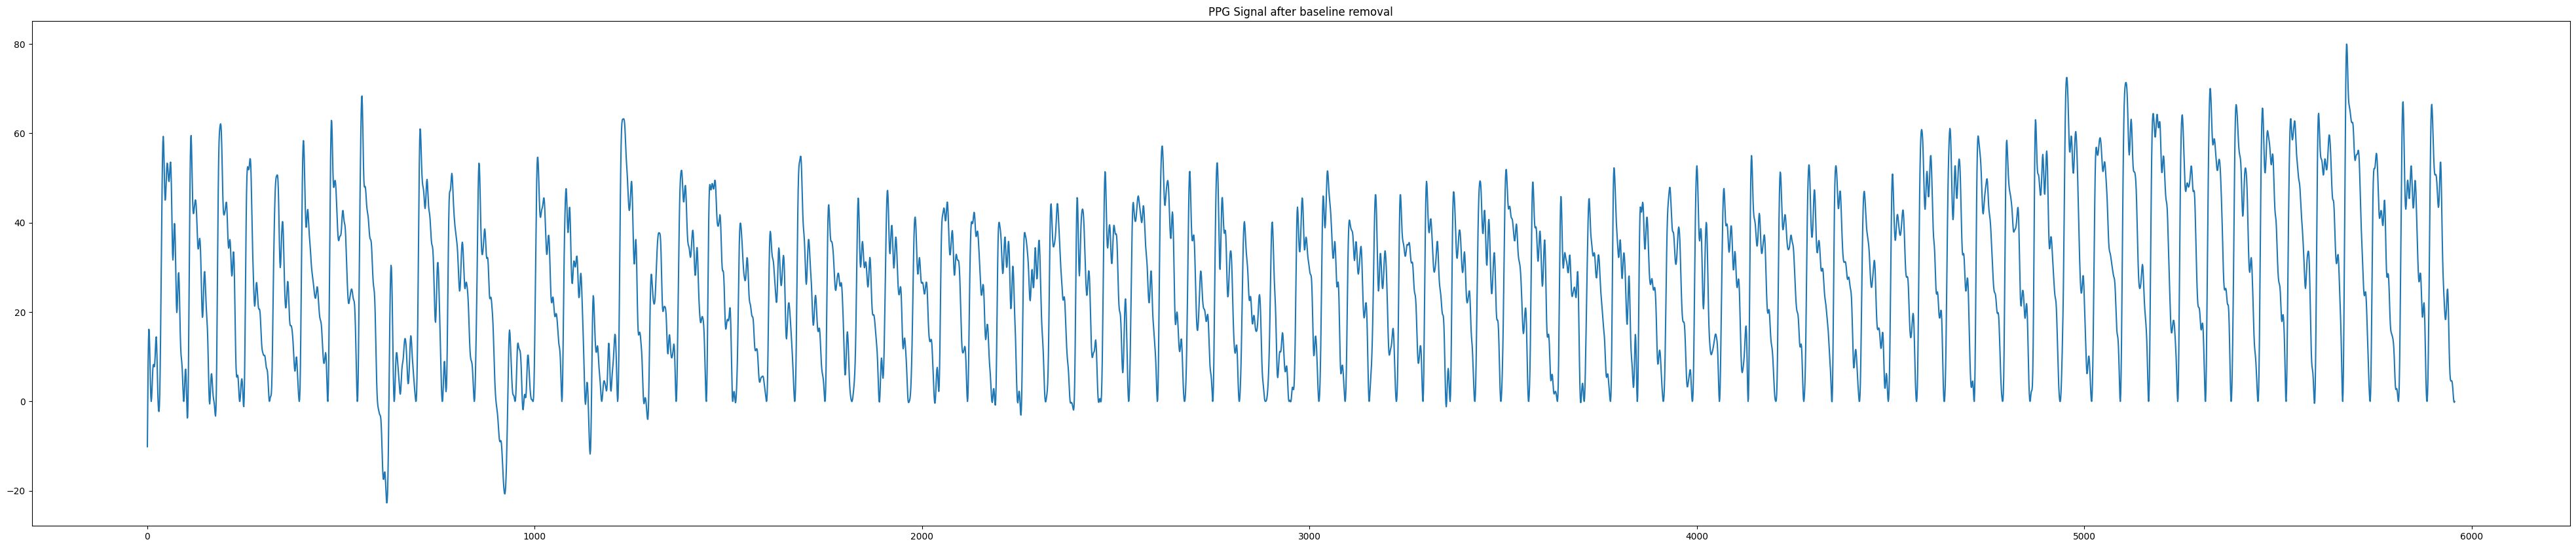

In [143]:
plt.figure(figsize=(50, 10))
plt.plot(signal_clean)
plt.title("PPG Signal after baseline removal")
plt.show()

In [144]:
segments = find_segments(signal_clean)
print(f"Found {len(segments)} segments")
# convert segments to df
segments_df = pd.DataFrame(segments)
print(segments_df.head())

Found 81 segments
   valid_h1_h2  valid_notch        H1        H2         n1         n2  \
0        False         True  0.607589  0.800000  11.227915  30.126415   
1        False         True  0.673515  0.689931  10.034439  28.538249   
2         True        False  0.759754  0.686359  11.612814  31.407468   
3         True         True  0.911450  0.428317  12.816010  34.019284   
4         True         True  0.798059  0.617567  17.578284  38.140935   

         W1    W2  idx_p1  idx_p2  idx_notch  highest_peak  dis_peak  \
0  4.428611  15.0      11      30         16      1.000000  0.906458   
1  3.788722  15.0      10      29         28      1.000000  0.599421   
2  4.952340  15.0      12      31         22      0.995177  0.648511   
3  6.590307  15.0      13      34         28      0.956464  0.489341   
4  5.865523  15.0      18      38         28      0.992894  0.599091   

      notch  segment_index  total_segments  valley_start  valley_end  \
0  0.768403              0            

In [ ]:
# get start of 1st segment and end of 30th segment
first_segment_start = segments_df.iloc[0]['valley_start']
last_segment_end = segments_df.iloc[min(NUM_OF_SEGMENTS - 1, len(segments_df) - 1)]['valley_end']
print(f"First segment starts at: {first_segment_start}")
print(f"Last segment ends at: {last_segment_end}")

First segment starts at: 30
Thirtieth segment ends at: 2319


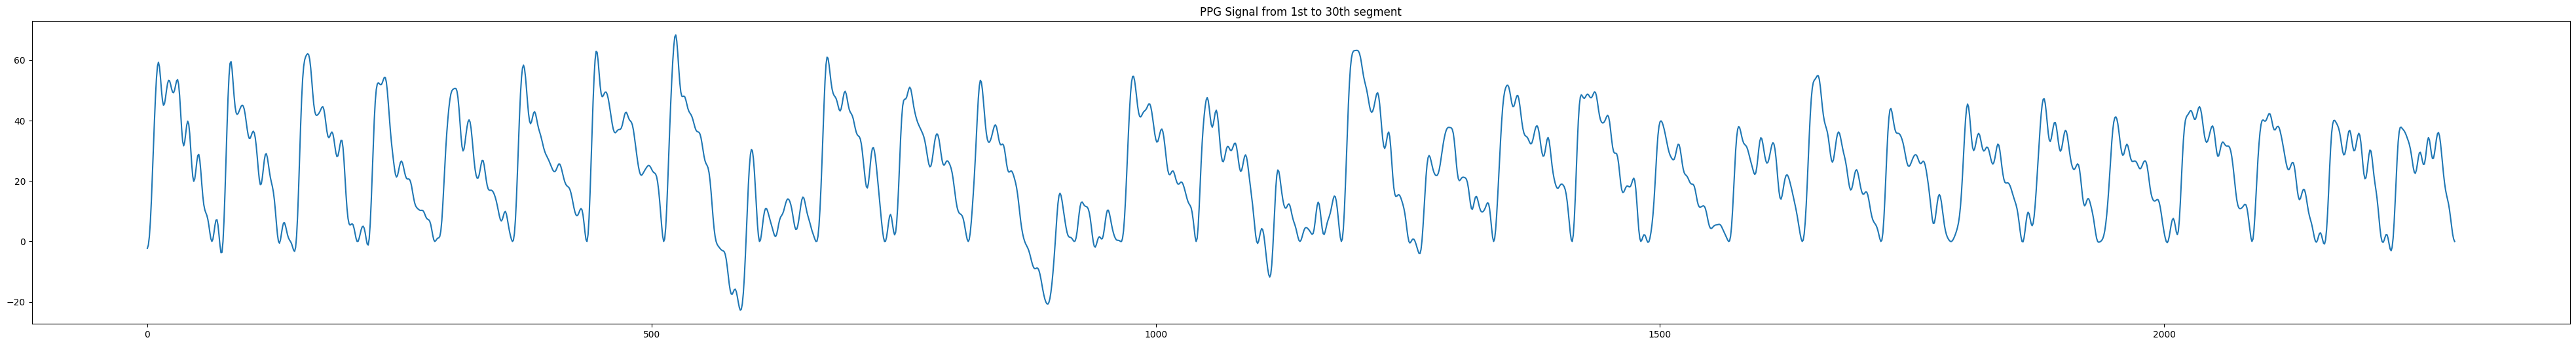

In [ ]:
signal_total_segments = signal_clean[first_segment_start:last_segment_end]
plt.figure(figsize=(50, 6))
plt.plot(signal_total_segments)
plt.title("PPG Signal from first to last segment: Total segments: " + str(min(NUM_OF_SEGMENTS, len(segments_df))))
plt.show()

In [ ]:
scaled_signal = min_max_scaler(signal_clean[first_segment_start:last_segment_end])
target_length = NUM_OF_SEGMENTS * SAMPLING_RATE  # 15 segments * 100 samples/segment = 1500 samples
final_signal = right_pad_or_crop(scaled_signal, target_length)

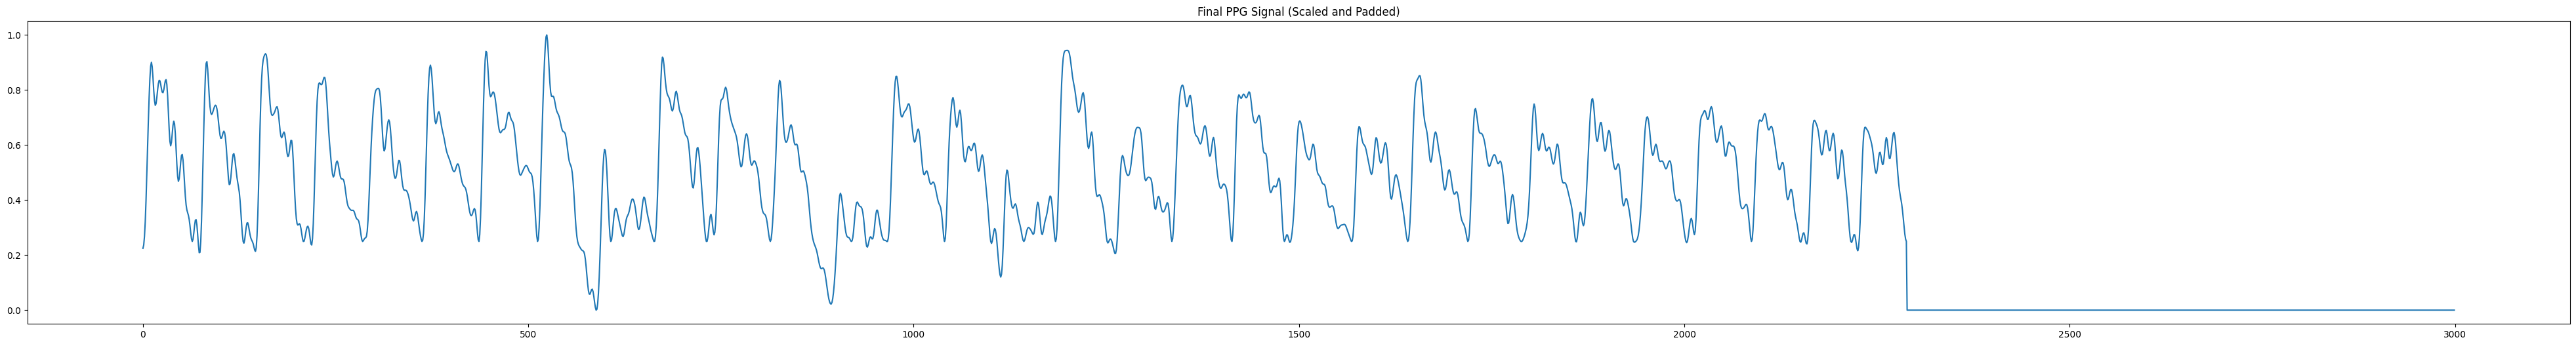

In [148]:
plt.figure(figsize=(50, 6))
plt.plot(final_signal)
plt.title("Final PPG Signal (Scaled and Padded)")
plt.show()

In [ ]:
model = ResNet16_Masked(input_len=target_length)
model.load_state_dict(torch.load('resnet16_bw_cs.pt', map_location=torch.device('cpu')))
model.eval()
with torch.no_grad():
    input_tensor = torch.tensor(final_signal, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    output = model(input_tensor, lengths=torch.tensor([len(final_signal)]))
    prediction = output.item()
    print(f"Predicted Blood Glucose Level: {prediction:.2f} mg/dL")

Predicted Blood Glucose Level: 120.59 mg/dL
